<a href="https://colab.research.google.com/github/mirzsreek/Ms.GREEN/blob/main/crop_disease_triage_training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crop Disease Triage — First Training Pass

Trains a MobileNetV2 classifier on **PlantVillage** with heavy augmentation to simulate bad phone photos, then validates on **PlantDoc** (real-world messy photos) to measure the robustness gap.

**Runtime:** Runtime > Change runtime type > GPU (T4 is fine).

## 1. Setup

In [10]:
!pip install -q kaggle tensorflow-datasets
import tensorflow as tf
import numpy as np
import os, zipfile, pathlib
print('TF version:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))


TF version: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2. Get PlantVillage (training data)

Easiest path: download from Kaggle. You'll need a `kaggle.json` API token (Kaggle account > Settings > Create New API Token), uploaded via the file browser on the left.

In [11]:
from google.colab import files
# Upload kaggle.json when prompted
uploaded = files.upload()
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Saving crop_disease_triage_training (1).ipynb to crop_disease_triage_training (1) (1).ipynb


In [12]:
!kaggle datasets download -d abdallahalidev/plantvillage-dataset -p /content/data --unzip
DATA_DIR = '/content/data'
!find /content/data -maxdepth 2 -type d | head -20


Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [01:34<00:00, 23.2MB/s]

/content/data
/content/data/plantvillage dataset
/content/data/plantvillage dataset/grayscale
/content/data/plantvillage dataset/color
/content/data/plantvillage dataset/segmented


## 3. Build the data pipeline with 'bad photo' augmentation

This is the core robustness trick: the source images are clean, so we corrupt them on the fly during training — blur, brightness/contrast shifts, noise, rotation, and random crop/occlusion — so the model learns to see past exactly the kind of degradation a farmer's phone photo will have.

In [13]:
IMG_SIZE = 224
BATCH_SIZE = 32

# We know the exact structure now: DATA_DIR/plantvillage dataset/{color,grayscale,segmented}/<class>/*.jpg
# We use 'color' since it matches real phone-camera RGB input.
class_root = pathlib.Path(DATA_DIR) / 'plantvillage dataset' / 'color'
assert class_root.exists(), f'Expected folder not found: {class_root}'
print('Using class root:', class_root)

full_ds = tf.keras.utils.image_dataset_from_directory(
    class_root, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    validation_split=0.15, subset='training', seed=42)
val_ds = tf.keras.utils.image_dataset_from_directory(
    class_root, image_size=(IMG_SIZE, IMG_SIZE), batch_size=BATCH_SIZE,
    validation_split=0.15, subset='validation', seed=42)

class_names = full_ds.class_names
num_classes = len(class_names)
print(num_classes, 'classes')

Using class root: /content/data/plantvillage dataset/color
Found 54305 files belonging to 38 classes.
Using 46160 files for training.
Found 54305 files belonging to 38 classes.
Using 8145 files for validation.
38 classes


In [14]:
def add_noise(img):
    noise = tf.random.normal(shape=tf.shape(img), mean=0.0, stddev=8.0)
    return tf.clip_by_value(img + noise, 0.0, 255.0)

def simulate_bad_photo(image, label):
    image = tf.image.random_flip_left_right(image)
    image = tf.image.random_brightness(image, max_delta=0.35)   # bad lighting
    image = tf.image.random_contrast(image, lower=0.5, upper=1.5)
    image = tf.image.random_saturation(image, lower=0.6, upper=1.4)
    image = tf.image.rot90(image, k=tf.random.uniform((), 0, 4, dtype=tf.int32))  # odd angles

    # random gaussian-ish blur via small average-pool, applied ~50% of the time
    if tf.random.uniform(()) > 0.5:
        image = tf.nn.avg_pool2d(image[None, ...], ksize=3, strides=1, padding='SAME')[0]

    image = add_noise(image)  # sensor noise / compression artifacts

    # random occlusion (dirt, shadow, cropped leaf) — simple rectangular blackout
    if tf.random.uniform(()) > 0.6:
        h, w = IMG_SIZE, IMG_SIZE
        ph, pw = h // 4, w // 4
        top = tf.random.uniform((), 0, h - ph, dtype=tf.int32)
        left = tf.random.uniform((), 0, w - pw, dtype=tf.int32)
        mask = tf.pad(tf.zeros((ph, pw, 3)),
                       [[top, h - top - ph], [left, w - left - pw], [0, 0]],
                       constant_values=1.0)
        image = image * mask

    image = tf.clip_by_value(image, 0.0, 255.0)
    return image, label

AUTOTUNE = tf.data.AUTOTUNE
train_ds = (full_ds.unbatch()
            .map(simulate_bad_photo, num_parallel_calls=AUTOTUNE)
            .batch(BATCH_SIZE)
            .prefetch(AUTOTUNE))
val_ds_clean = val_ds.prefetch(AUTOTUNE)  # keep a clean val set to track base accuracy too

## 4. Build the model (MobileNetV2 transfer learning)

In [15]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet')
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = tf.keras.applications.mobilenet_v2.preprocess_input(inputs)
x = base_model(x, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)
model = tf.keras.Model(inputs, outputs)

model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 5. Train (phase 1: frozen base)

In [16]:
EPOCHS_PHASE1 = 8
history = model.fit(train_ds, validation_data=val_ds_clean, epochs=EPOCHS_PHASE1)


Epoch 1/8
   1443/Unknown 350s 228ms/step - accuracy: 0.6357 - loss: 1.3318

/usr/local/lib/python3.13/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1443/1443 ━━━━━━━━━━━━━━━━━━━━ 374s 246ms/step - accuracy: 0.7450 - loss: 0.8701 - val_accuracy: 0.8546 - val_loss: 0.4654
Epoch 2/8
1443/1443 ━━━━━━━━━━━━━━━━━━━━ 328s 227ms/step - accuracy: 0.8309 - loss: 0.5271 - val_accuracy: 0.8759 - val_loss: 0.3826
Epoch 3/8
1443/1443 ━━━━━━━━━━━━━━━━━━━━ 326s 226ms/step - accuracy: 0.8451 - loss: 0.4925 - val_accuracy: 0.8766 - val_loss: 0.3895
Epoch 4/8
1443/1443 ━━━━━━━━━━━━━━━━━━━━ 329s 228ms/step - accuracy: 0.8483 - loss: 0.4768 - val_accuracy: 0.8870 - val_loss: 0.3377
Epoch 5/8
1443/1443 ━━━━━━━━━━━━━━━━━━━━ 324s 224ms/step - accuracy: 0.8506 - loss: 0.4653 - val_accuracy: 0.8926 - val_loss: 0.3249
Epoch 6/8
1443/1443 ━━━━━━━━━━━━━━━━━━━━ 384s 226ms/step - accuracy: 0.8550 - loss: 0.4629 - val_accuracy: 0.8742 - val_loss: 0.3570
Epoch 7/8
1443/1443 ━━━━━━━━━━━━━━━━━━━━ 380s 225ms/step - accuracy: 0.8560 - loss: 0.4530 - val_accuracy: 0.8699 - val_loss: 0.3765
Epoch 8/8
1443/1443 ━━━━━━━━━━━━━━━━━━━━ 381s 224ms/step - accuracy: 0.8584 - l

## 6. Fine-tune (phase 2: unfreeze top layers)

Unfreezes the last chunk of MobileNetV2 and trains with a low learning rate — squeezes out extra accuracy once the new head has stabilized.

In [17]:
base_model.trainable = True
for layer in base_model.layers[:-30]:
    layer.trainable = False

model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

EPOCHS_PHASE2 = 6
history_ft = model.fit(train_ds, validation_data=val_ds_clean, epochs=EPOCHS_PHASE2)


Epoch 1/6
1443/1443 ━━━━━━━━━━━━━━━━━━━━ 360s 238ms/step - accuracy: 0.7898 - loss: 0.7700 - val_accuracy: 0.8993 - val_loss: 0.3088
Epoch 2/6
1443/1443 ━━━━━━━━━━━━━━━━━━━━ 326s 226ms/step - accuracy: 0.8647 - loss: 0.4199 - val_accuracy: 0.9164 - val_loss: 0.2473
Epoch 3/6
1443/1443 ━━━━━━━━━━━━━━━━━━━━ 383s 227ms/step - accuracy: 0.8867 - loss: 0.3483 - val_accuracy: 0.9228 - val_loss: 0.2273
Epoch 4/6
1443/1443 ━━━━━━━━━━━━━━━━━━━━ 325s 225ms/step - accuracy: 0.8977 - loss: 0.3088 - val_accuracy: 0.9306 - val_loss: 0.2047
Epoch 5/6
1443/1443 ━━━━━━━━━━━━━━━━━━━━ 323s 224ms/step - accuracy: 0.9068 - loss: 0.2752 - val_accuracy: 0.9387 - val_loss: 0.1831
Epoch 6/6
1443/1443 ━━━━━━━━━━━━━━━━━━━━ 330s 229ms/step - accuracy: 0.9156 - loss: 0.2541 - val_accuracy: 0.9439 - val_loss: 0.1718


## 7. Validate on PlantDoc (real-world messy photos)

This is the number that actually matters: how much does accuracy drop on genuinely real-world photos compared to the clean PlantVillage validation set? A big drop means the augmentation in step 3 needs to be stronger.

In [18]:
!git clone -q https://github.com/pratikkayal/PlantDoc-Dataset.git /content/plantdoc
PLANTDOC_DIR = '/content/plantdoc/train'  # check repo structure after clone; may need 'test' too

# Note: PlantDoc's class names won't exactly match PlantVillage's — you'll need to write a small
# mapping dict from PlantDoc folder names to your class_names before this eval will run cleanly.
# This is expected extra work, not a bug — flagging it here rather than hiding it.
print('Inspect /content/plantdoc to build the label mapping before running eval.')


Inspect /content/plantdoc to build the label mapping before running eval.


In [19]:
!ls /content/plantdoc/train

'Apple leaf'		    'Potato leaf late blight'
'Apple rust leaf'	    'Raspberry leaf'
'Apple Scab Leaf'	    'Soyabean leaf'
'Bell_pepper leaf'	    'Squash Powdery mildew leaf'
'Bell_pepper leaf spot'     'Strawberry leaf'
'Blueberry leaf'	    'Tomato Early blight leaf'
'Cherry leaf'		    'Tomato leaf'
'Corn Gray leaf spot'	    'Tomato leaf bacterial spot'
'Corn leaf blight'	    'Tomato leaf late blight'
'Corn rust leaf'	    'Tomato leaf mosaic virus'
'grape leaf'		    'Tomato leaf yellow virus'
'grape leaf black rot'	    'Tomato mold leaf'
'Peach leaf'		    'Tomato Septoria leaf spot'
'Potato leaf early blight'  'Tomato two spotted spider mites leaf'


In [20]:
print(class_names)

['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight', 'Corn_(maize)___healthy', 'Grape___Black_rot', 'Grape___Esca_(Black_Measles)', 'Grape___Leaf_blight_(Isariopsis_Leaf_Spot)', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Peach___Bacterial_spot', 'Peach___healthy', 'Pepper,_bell___Bacterial_spot', 'Pepper,_bell___healthy', 'Potato___Early_blight', 'Potato___Late_blight', 'Potato___healthy', 'Raspberry___healthy', 'Soybean___healthy', 'Squash___Powdery_mildew', 'Strawberry___Leaf_scorch', 'Strawberry___healthy', 'Tomato___Bacterial_spot', 'Tomato___Early_blight', 'Tomato___Late_blight', 'Tomato___Leaf_Mold', 'Tomato___Septoria_leaf_spot', 'Tomato___Spider_mites Two-spotted_spider_mite', 'Tomato___Target_Sp

In [21]:
import pathlib
import numpy as np

plantdoc_to_plantvillage = {
    'Apple leaf': 'Apple___healthy',
    'Apple rust leaf': 'Apple___Cedar_apple_rust',
    'Apple Scab Leaf': 'Apple___Apple_scab',
    'Bell_pepper leaf': 'Pepper,_bell___healthy',
    'Bell_pepper leaf spot': 'Pepper,_bell___Bacterial_spot',
    'Blueberry leaf': 'Blueberry___healthy',
    'Cherry leaf': 'Cherry_(including_sour)___healthy',
    'Corn Gray leaf spot': 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot',
    'Corn leaf blight': 'Corn_(maize)___Northern_Leaf_Blight',
    'Corn rust leaf': 'Corn_(maize)___Common_rust_',
    'grape leaf': 'Grape___healthy',
    'grape leaf black rot': 'Grape___Black_rot',
    'Peach leaf': 'Peach___healthy',
    'Potato leaf early blight': 'Potato___Early_blight',
    'Potato leaf late blight': 'Potato___Late_blight',
    'Raspberry leaf': 'Raspberry___healthy',
    'Soyabean leaf': 'Soybean___healthy',
    'Squash Powdery mildew leaf': 'Squash___Powdery_mildew',
    'Strawberry leaf': 'Strawberry___healthy',
    'Tomato Early blight leaf': 'Tomato___Early_blight',
    'Tomato leaf': 'Tomato___healthy',
    'Tomato leaf bacterial spot': 'Tomato___Bacterial_spot',
    'Tomato leaf late blight': 'Tomato___Late_blight',
    'Tomato leaf mosaic virus': 'Tomato___Tomato_mosaic_virus',
    'Tomato leaf yellow virus': 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
    'Tomato mold leaf': 'Tomato___Leaf_Mold',
    'Tomato Septoria leaf spot': 'Tomato___Septoria_leaf_spot',
    'Tomato two spotted spider mites leaf': 'Tomato___Spider_mites Two-spotted_spider_mite',
    # No PlantVillage match available in our 38 classes — skipped:
    # 'Bell_pepper leaf spot' (dup, mapped above)
}

plantdoc_root = pathlib.Path('/content/plantdoc/train')
class_to_idx = {name: i for i, name in enumerate(class_names)}

eval_images, eval_labels = [], []
for folder in plantdoc_root.iterdir():
    if not folder.is_dir():
        continue
    pv_class = plantdoc_to_plantvillage.get(folder.name)
    if pv_class is None:
        continue  # no matching PlantVillage class, skip
    label_idx = class_to_idx[pv_class]
    for img_path in folder.glob('*.*'):
        eval_images.append(str(img_path))
        eval_labels.append(label_idx)

print(f'Usable PlantDoc images: {len(eval_images)} across {len(set(eval_labels))} mapped classes')

def load_and_preprocess(path):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, (IMG_SIZE, IMG_SIZE))
    return img

plantdoc_ds = tf.data.Dataset.from_tensor_slices((eval_images, eval_labels))
plantdoc_ds = plantdoc_ds.map(lambda p, l: (load_and_preprocess(p), l)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

loss, acc = model.evaluate(plantdoc_ds)
print(f'PlantDoc (real-world) accuracy: {acc:.4f}')

Usable PlantDoc images: 2342 across 28 mapped classes
74/74 ━━━━━━━━━━━━━━━━━━━━ 40s 537ms/step - accuracy: 0.1567 - loss: 9.2579
PlantDoc (real-world) accuracy: 0.1567


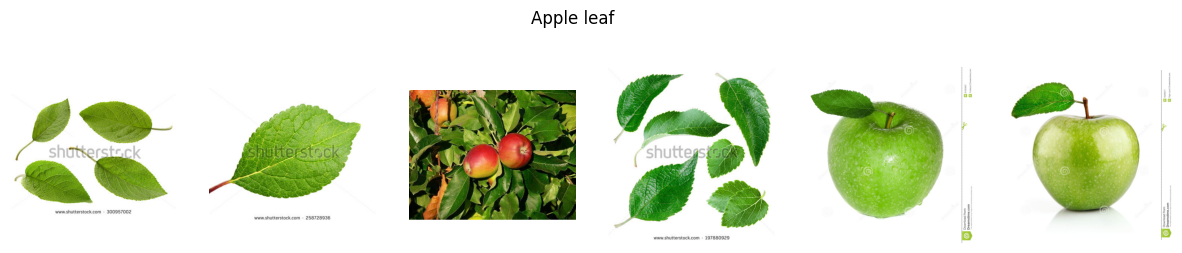

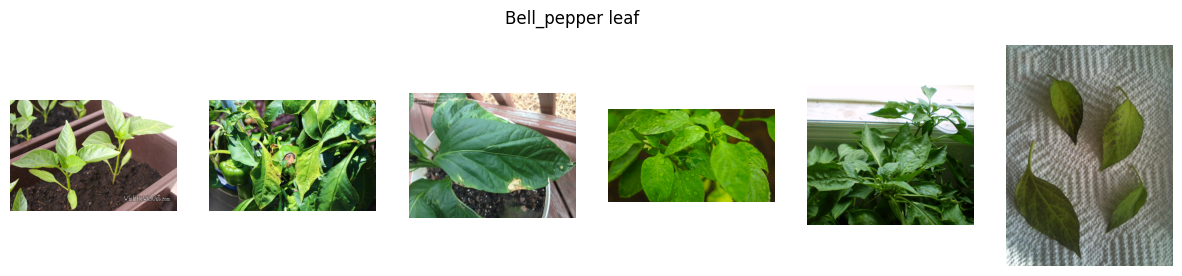

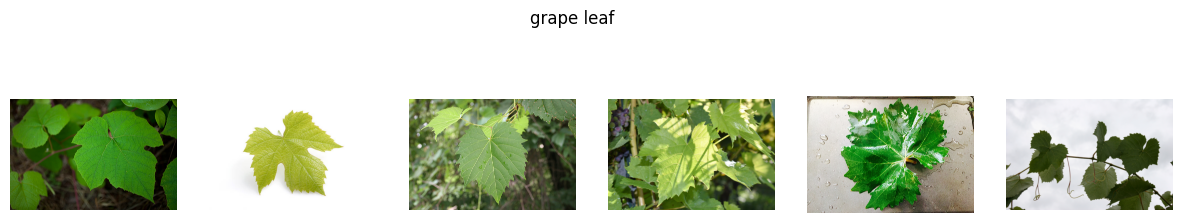

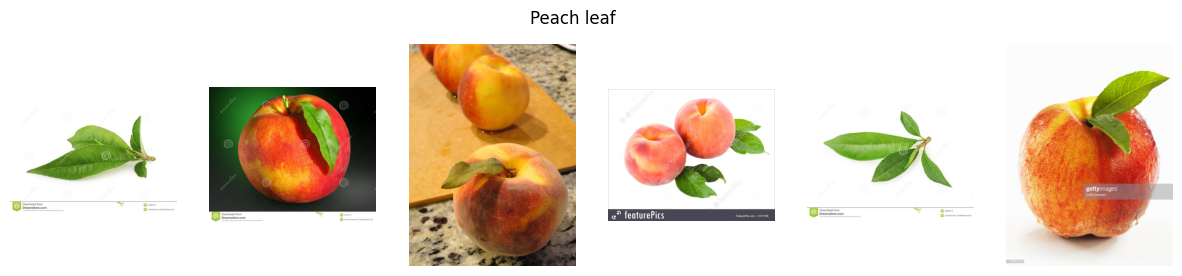

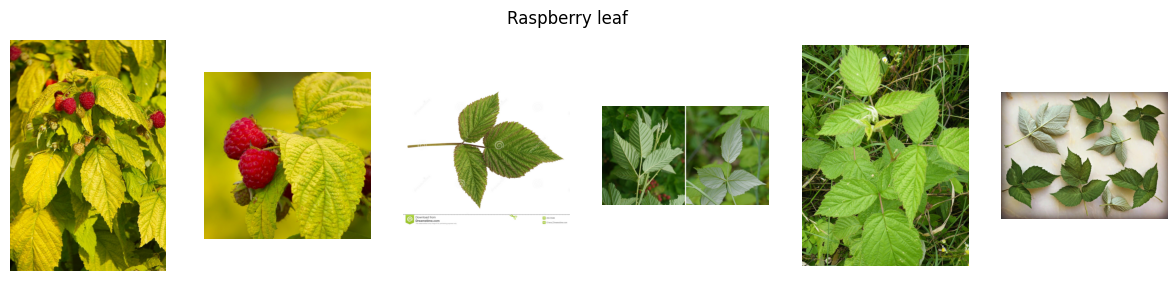

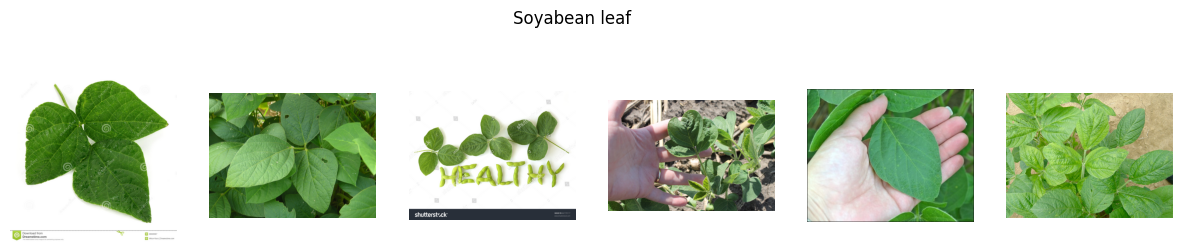

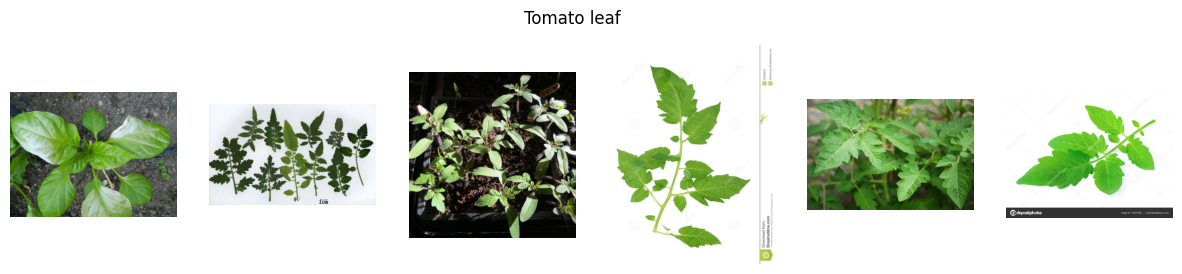

In [22]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

ambiguous_folders = ['Apple leaf', 'Bell_pepper leaf', 'grape leaf', 'Peach leaf',
                      'Raspberry leaf', 'Soyabean leaf', 'Tomato leaf']

for folder_name in ambiguous_folders:
    folder = pathlib.Path('/content/plantdoc/train') / folder_name
    imgs = list(folder.glob('*.*'))[:6]
    fig, axes = plt.subplots(1, len(imgs), figsize=(15, 3))
    fig.suptitle(folder_name)
    for ax, img_path in zip(axes, imgs):
        ax.imshow(mpimg.imread(img_path))
        ax.axis('off')
    plt.show()

In [23]:
from sklearn.model_selection import train_test_split

train_paths, test_paths, train_labels, test_labels = train_test_split(
    eval_images, eval_labels, test_size=0.3, random_state=42, stratify=eval_labels
)

print(f'Fine-tune set: {len(train_paths)} images')
print(f'Held-out test set: {len(test_paths)} images')

def make_ds(paths, labels, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    ds = ds.map(lambda p, l: (load_and_preprocess(p), l), num_parallel_calls=tf.data.AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(len(paths))
    return ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

plantdoc_finetune_ds = make_ds(train_paths, train_labels, shuffle=True)
plantdoc_test_ds = make_ds(test_paths, test_labels)

# baseline check on the held-out slice BEFORE fine-tuning, for a fair before/after comparison
pre_loss, pre_acc = model.evaluate(plantdoc_test_ds)
print(f'Held-out accuracy BEFORE fine-tuning: {pre_acc:.4f}')

Fine-tune set: 1639 images
Held-out test set: 703 images
22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 997ms/step - accuracy: 0.1565 - loss: 9.1753
Held-out accuracy BEFORE fine-tuning: 0.1565


In [24]:
# fine-tune on real PlantDoc data at a very low learning rate
model.compile(optimizer=tf.keras.optimizers.Adam(1e-5),
              loss='sparse_categorical_crossentropy', metrics=['accuracy'])

finetune_history = model.fit(
    plantdoc_finetune_ds,
    validation_data=plantdoc_test_ds,
    epochs=10
)

Epoch 1/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 74s 673ms/step - accuracy: 0.2105 - loss: 5.5523 - val_accuracy: 0.1707 - val_loss: 8.5517
Epoch 2/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 28s 182ms/step - accuracy: 0.2465 - loss: 4.2644 - val_accuracy: 0.1920 - val_loss: 7.8658
Epoch 3/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 31s 200ms/step - accuracy: 0.2971 - loss: 3.4589 - val_accuracy: 0.2020 - val_loss: 7.1702
Epoch 4/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 28s 199ms/step - accuracy: 0.3301 - loss: 2.9946 - val_accuracy: 0.2248 - val_loss: 6.5086
Epoch 5/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 42s 244ms/step - accuracy: 0.3441 - loss: 2.6283 - val_accuracy: 0.2546 - val_loss: 5.9023
Epoch 6/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 27s 170ms/step - accuracy: 0.4002 - loss: 2.2941 - val_accuracy: 0.2717 - val_loss: 5.3837
Epoch 7/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 27s 168ms/step - accuracy: 0.4167 - loss: 2.1346 - val_accuracy: 0.2973 - val_loss: 4.9082
Epoch 8/10
52/52 ━━━━━━━━━━━━━━━━━━━━ 41s 195ms/step - accuracy: 0.4411 - loss: 1.9468 - val_accu

In [25]:
finetune_history_2 = model.fit(
    plantdoc_finetune_ds,
    validation_data=plantdoc_test_ds,
    epochs=15
)

Epoch 1/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 31s 194ms/step - accuracy: 0.4936 - loss: 1.6248 - val_accuracy: 0.3656 - val_loss: 3.5343
Epoch 2/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 27s 193ms/step - accuracy: 0.5442 - loss: 1.5128 - val_accuracy: 0.3684 - val_loss: 3.2958
Epoch 3/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 40s 170ms/step - accuracy: 0.5552 - loss: 1.4303 - val_accuracy: 0.3841 - val_loss: 3.0925
Epoch 4/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 30s 243ms/step - accuracy: 0.5973 - loss: 1.3244 - val_accuracy: 0.4026 - val_loss: 2.9192
Epoch 5/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 29s 242ms/step - accuracy: 0.5906 - loss: 1.3081 - val_accuracy: 0.4196 - val_loss: 2.7701
Epoch 6/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 27s 193ms/step - accuracy: 0.6193 - loss: 1.2395 - val_accuracy: 0.4324 - val_loss: 2.6431
Epoch 7/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 29s 243ms/step - accuracy: 0.6327 - loss: 1.1649 - val_accuracy: 0.4395 - val_loss: 2.5349
Epoch 8/15
52/52 ━━━━━━━━━━━━━━━━━━━━ 38s 169ms/step - accuracy: 0.6553 - loss: 1.0833 - val_accu

## 8. Save the model (Keras + TFLite for on-device use)

In [26]:
model.save('/content/crop_disease_model.keras')

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]  # quantize for phone deployment
tflite_model = converter.convert()
with open('/content/crop_disease_model.tflite', 'wb') as f:
    f.write(tflite_model)

import json
with open('/content/class_names.json', 'w') as f:
    json.dump(class_names, f)

print('Saved: crop_disease_model.keras, crop_disease_model.tflite, class_names.json')


Saved artifact at '/tmp/tmpa91k0ie9'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  138597374595280: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138597374778192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138597374786448: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138597594043728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138597376412560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138597593494160: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138597592264400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138597592259984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138597593484560: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138597593484368: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138597593

## Next steps
- Build the label mapping for PlantDoc and run the real-world validation in step 7.
- Add the pre-diagnosis quality gate (blur/brightness/leaf-presence check) as a separate lightweight step before this model runs.
- Add confidence-threshold logic on top of `model.predict()` output for the abstention behavior ("not sure" responses).
- Wrap `crop_disease_model.tflite` into the mobile app for offline inference.